In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
base_dir = 'dataset'
IMG_SIZE = 64
LIMIT_PER_CLASS = 50

In [5]:
# ==========================================
# 2. FUNGSI PREPROCESSING & LOADING
# ==========================================
def load_data(directory, size, limit):
    X, y = [], []
    categories = sorted(os.listdir(directory))
    label_map = {cat: i for i, cat in enumerate(categories)}
    
    print(f"Memulai loading data (Limit: {limit} per kategori)...")
    for category in categories:
        path = os.path.join(directory, category)
        images = os.listdir(path)[:limit]
        print(f" - Mengambil {len(images)} gambar dari {category}")
        for img_name in images:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (size, size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img / 255.0) # Normalisasi ke 0-1
                y.append(label_map[category])
    
    X = np.array(X)
    y = np.array(y).astype(int) # Pastikan integer untuk indexing
    return X, y, categories

def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

In [6]:
# ==========================================
# 3. FUNGSI CNN MANUAL (CORE)
# ==========================================
def manual_conv(image, kernel, stride=1, padding=True):
    h_i, w_i, c_i = image.shape
    h_k, w_k, c_k, n_f = kernel.shape
    p = (h_k - 1) // 2 if padding else 0
    
    if padding:
        image = np.pad(image, ((p, p), (p, p), (0, 0)), mode='constant')
        
    h_o = (h_i - h_k + 2*p) // stride + 1
    w_o = (w_i - w_k + 2*p) // stride + 1
    output = np.zeros((h_o, w_o, n_f))
    
    for f in range(n_f):
        for i in range(h_o):
            for j in range(w_o):
                region = image[i*stride:i*stride+h_k, j*stride:j*stride+w_k, :]
                output[i, j, f] = np.sum(region * kernel[:,:,:,f])
    return output

def manual_relu(x):
    return np.maximum(0, x)

def manual_maxpool(x, size=2, stride=2):
    h_i, w_i, c_i = x.shape
    h_o = (h_i - size) // stride + 1
    w_o = (w_i - size) // stride + 1
    output = np.zeros((h_o, w_o, c_i))
    for c in range(c_i):
        for i in range(h_o):
            for j in range(w_o):
                output[i, j, c] = np.max(x[i*stride:i*stride+size, j*stride:j*stride+size, c])
    return output

def manual_softmax(x):
    exps = np.exp(x - np.max(x))
    return exps / np.sum(exps)


In [18]:
# ==========================================
# 4. EKSEKUSI PIPELINE
# ==========================================

# A. Load & Shuffle Data
X_all, y_all, label_names = load_data(base_dir, IMG_SIZE, LIMIT_PER_CLASS)
indices = np.arange(len(X_all))
np.random.seed(42) # Agar hasil konsisten
np.random.shuffle(indices)
X_all, y_all = X_all[indices], y_all[indices]

Memulai loading data (Limit: 50 per kategori)...
 - Mengambil 50 gambar dari cataract
 - Mengambil 50 gambar dari diabetic_retinopathy
 - Mengambil 50 gambar dari glaucoma
 - Mengambil 50 gambar dari normal


In [23]:


# B. Inisialisasi Parameter Awal (Random Weights)
num_classes = len(label_names)
# Kernel: 3x3, 3 input channel, 8 filter
kernel_1 = np.random.randn(3, 3, 3, 8) * 0.1 
# Output Pool: (64/2) * (64/2) * 8 filters = 32 * 32 * 8 = 8192
fc_input_size = (IMG_SIZE // 2) * (IMG_SIZE // 2) * 8 
weights_fc = np.random.randn(fc_input_size, num_classes) * 0.01
bias_fc = np.zeros(num_classes)

# C. Forward Pass untuk Satu Sampel (Uji Coba)
sample_idx = np.random.randint(0, len(X_all))
img = X_all[sample_idx]

# Jalankan rangkaian layer
out_conv  = manual_conv(img, kernel_1, stride=1, padding=True)
out_relu  = manual_relu(out_conv)
out_pool  = manual_maxpool(out_relu, size=2, stride=2)
out_flat  = out_pool.flatten()
logits    = np.dot(out_flat, weights_fc) + bias_fc
probs     = manual_softmax(logits)


HASIL PREDIKSI AWAL (BOBOT ACAK)
Label Asli : cataract
cataract            :  22.73% [MATCH]
diabetic_retinopathy:  33.40% 
glaucoma            :  21.02% 
normal              :  22.85% 


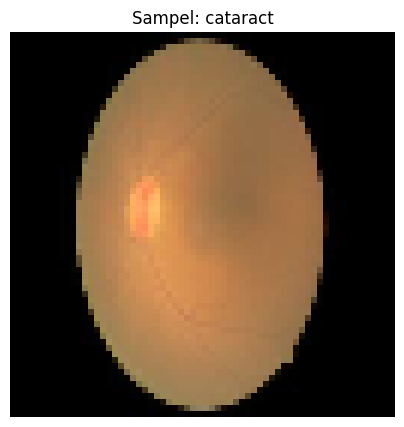

In [27]:
# ==========================================
# 5. VISUALISASI HASIL
# ==========================================
print("\n" + "="*40)
print(f"HASIL PREDIKSI AWAL (BOBOT ACAK)")
print(f"Label Asli : {label_names[y_all[sample_idx]]}")
print("="*40)

for i, name in enumerate(label_names):
    status = "[MATCH]" if i == y_all[sample_idx] else ""
    print(f"{name:20}: {probs[i]*100:6.2f}% {status}")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Sampel: {label_names[y_all[sample_idx]]}")
plt.axis('off')
plt.show()

## **Evaluasi CNN**

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns # Opsional, untuk visualisasi matriks yang lebih cantik

In [31]:
y_preds = []
y_true = y_all # Label asli yang sudah kita simpan sebelumnya

print("Sedang memproses prediksi seluruh data (mohon tunggu)...")
for i in range(len(X_all)):
    # Forward Pass Manual
    img = X_all[i]
    conv = manual_conv(img, kernel_1)
    relu = manual_relu(conv)
    pool = manual_maxpool(relu)
    flat = pool.flatten()
    logits = np.dot(flat, weights_fc) + bias_fc
    
    # Ambil indeks kelas dengan nilai tertinggi
    pred = np.argmax(manual_softmax(logits))
    y_preds.append(pred)

print("Prediksi selesai!")

Sedang memproses prediksi seluruh data (mohon tunggu)...
Prediksi selesai!



CLASSIFICATION REPORT (SKLEARN)
                      precision    recall  f1-score   support

            cataract       0.00      0.00      0.00        50
diabetic_retinopathy       0.25      1.00      0.40        50
            glaucoma       0.00      0.00      0.00        50
              normal       0.00      0.00      0.00        50

            accuracy                           0.25       200
           macro avg       0.06      0.25      0.10       200
        weighted avg       0.06      0.25      0.10       200

Overall Accuracy: 25.00%


/home/hujan/miniconda3/envs/biomedika/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hujan/miniconda3/envs/biomedika/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hujan/miniconda3/envs/biomedika/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

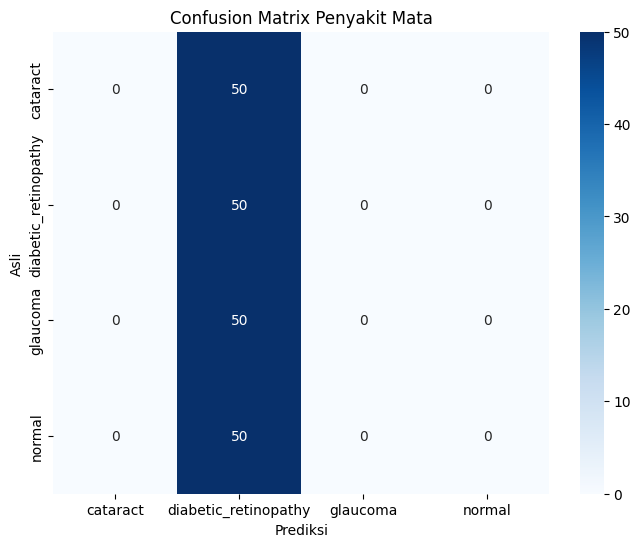

In [32]:
# 1. Cetak Laporan Klasifikasi
print("\n" + "="*60)
print("CLASSIFICATION REPORT (SKLEARN)")
print("="*60)
# target_names akan menampilkan nama kategori seperti 'Cataract', 'Normal', dll.
print(classification_report(y_true, y_preds, target_names=label_names))

# 2. Cetak Akurasi Keseluruhan
acc = accuracy_score(y_true, y_preds)
print(f"Overall Accuracy: {acc*100:.2f}%")

# 3. Visualisasi Confusion Matrix agar lebih mudah dibaca
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Asli')
plt.title('Confusion Matrix Penyakit Mata')
plt.show()